In [12]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


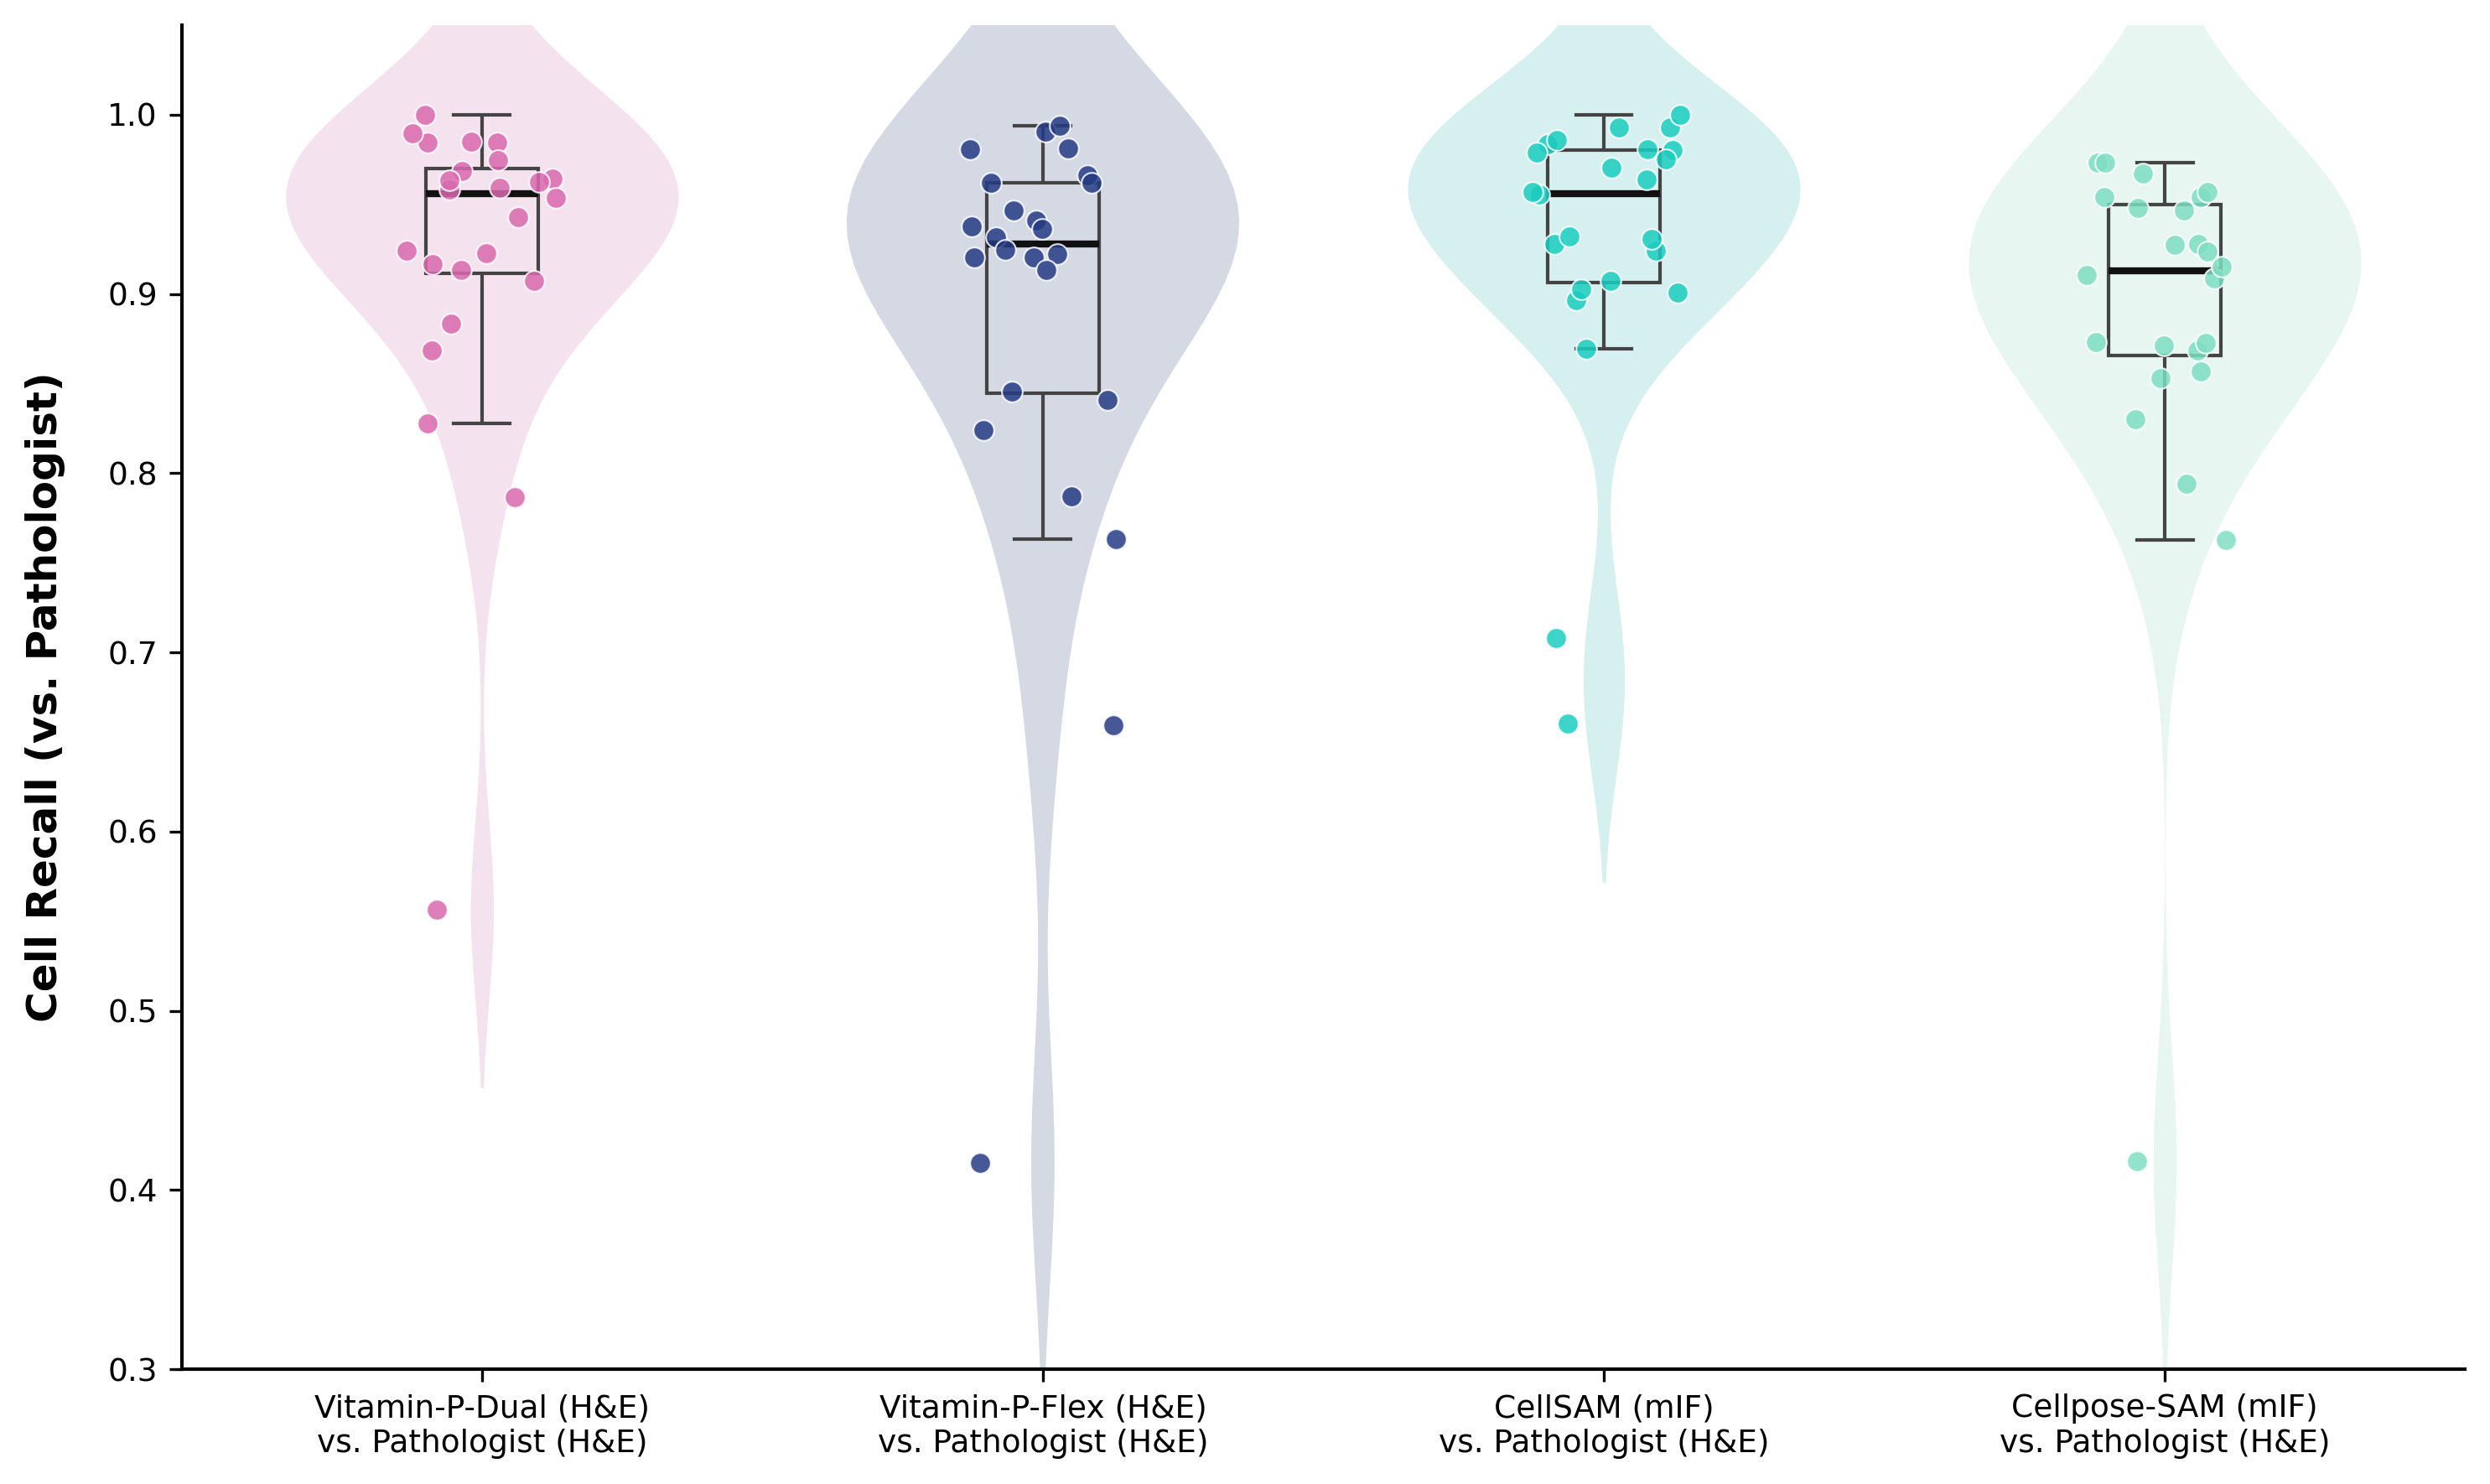

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- AI/Illustrator Compatibility ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 9
})

# --- Updated Model Order for Recall ---
order = [
    'Vitamin-P-Dual (H&E)\nvs. Pathologist (H&E)',
    'Vitamin-P-Flex (H&E)\nvs. Pathologist (H&E)',
    'CellSAM (mIF)\nvs. Pathologist (H&E)',
    'Cellpose-SAM (mIF)\nvs. Pathologist (H&E)'
]

# --- Generating Dummy Data for Recall (Replace this with real data later) ---
np.random.seed(42)
n_samples = 24
data_dict = {
    order[0]: [0.9687, 0.9643, 0.9427, 0.9847, 0.8278, 0.9845, 0.9898, 0.9624, 0.9745, 0.7864, 0.9242, 0.9535, 0.9074, 0.5564, 0.8685, 0.9169, 0.8836, 0.9227, 0.9849, 0.9584, 0.9592, 1.0000, 0.9635, 0.9132],
    order[1]: [0.9410, 0.9663, 0.9315, 0.9908, 0.9224, 0.9378, 0.9939, 0.9621, 0.9204, 0.6594, 0.7634, 0.9620, 0.8458, 0.4154, 0.7872, 0.9202, 0.8242, 0.9364, 0.9806, 0.8408, 0.9245, 0.9812, 0.9466, 0.9132],
    order[2]: [0.9703, 0.9281, 0.9008, 0.9806, 0.9805, 0.9752, 0.9929, 0.9928, 0.9553, 0.7079, 0.9571, 0.8967, 0.8692, 0.6603, 0.9240, 0.9028, 0.9319, 0.9075, 0.9834, 0.9306, 0.9791, 1.0000, 0.9639, 0.9860],
    order[3]: [0.9106, 0.9087, 0.8685, 0.9542, 0.9570, 0.9733, 0.9674, 0.9543, 0.9152, 0.9466, 0.9482, 0.8731, 0.8299, 0.4160, 0.8570, 0.7940, 0.7628, 0.8530, 0.9731, 0.9278, 0.8728, 0.9274, 0.9238, 0.8713]
}

df = pd.DataFrame([(m, s) for m, scores in data_dict.items() for s in scores], columns=['Model', 'recall'])

# --- Aesthetic Setup ---
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

colors = {
    order[0]: '#d969ae',  # Magenta
    order[1]: '#253c84',  # Deep Blue
    order[2]: '#1bcdc0',  # Teal
    order[3]: '#7edec2'   # Light Teal
}

# 1. Violin Plot
sns.violinplot(data=df, x='Model', y='recall', ax=ax, order=order, palette=colors, 
               hue='Model', legend=False, inner=None, alpha=0.2, linewidth=0, width=0.7, 
               density_norm='width', zorder=2)

# 2. Boxplot
sns.boxplot(data=df, x='Model', y='recall', ax=ax, order=order,
            boxprops={'facecolor': 'none', 'linewidth': 1.0, 'edgecolor': '#444444'},
            medianprops={'linewidth': 2.0, 'color': '#111111'},
            whiskerprops={'linewidth': 1.0, 'color': '#444444'},
            capprops={'linewidth': 1.0, 'color': '#444444'},
            flierprops={'marker': ''}, width=0.2, zorder=3)

# 3. Scatter Jitter
for i, model in enumerate(order):
    subset = df[df['Model'] == model]['recall'].values
    x_pos = i + np.random.uniform(-0.14, 0.14, size=len(subset))
    ax.scatter(x_pos, subset, color=colors[model], s=35, alpha=0.85, 
                edgecolors='white', linewidths=0.5, zorder=5)

# --- Final Labels ---
ax.set_ylabel('Cell Recall (vs. Pathologist)', fontweight='bold', fontsize=12, labelpad=12)
ax.set_xlabel('')
ax.set_ylim(0.30, 1.05) 
plt.xticks(fontsize=9)

plt.tight_layout()
plt.show()

## Dcie

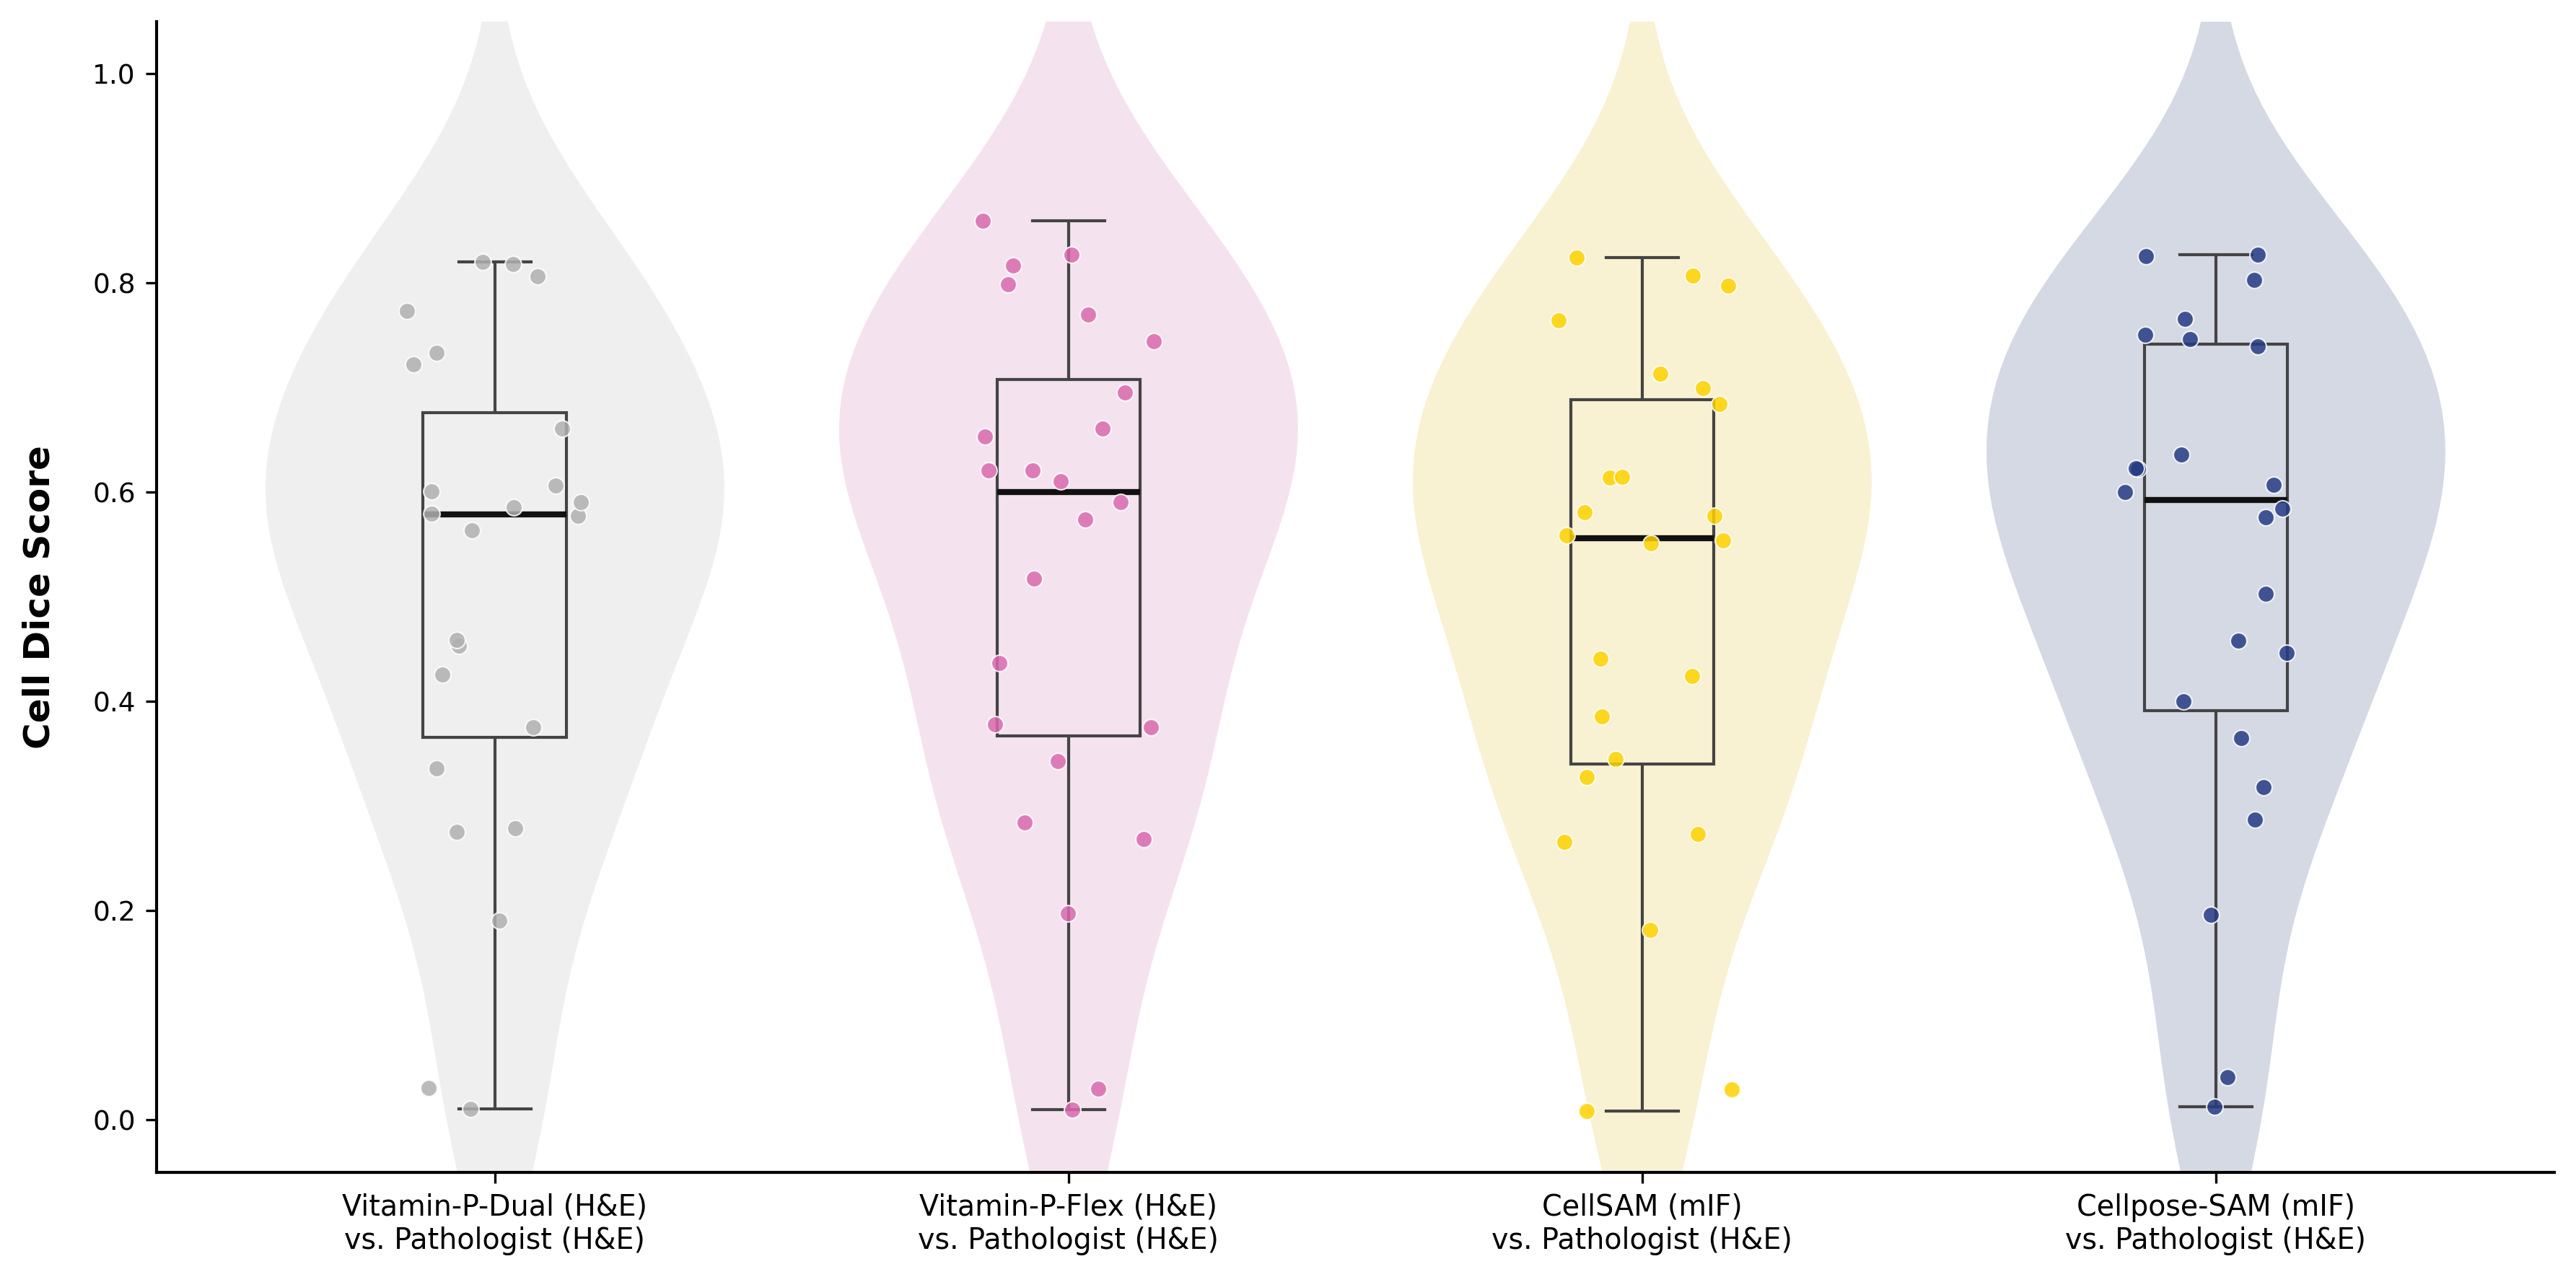

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'Arial'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.0, 'axes.labelsize': 10,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9
})

order = [
    'Vitamin-P-Dual (H&E)\nvs. Pathologist (H&E)',
    'Vitamin-P-Flex (H&E)\nvs. Pathologist (H&E)',
    'CellSAM (mIF)\nvs. Pathologist (H&E)',
    'Cellpose-SAM (mIF)\nvs. Pathologist (H&E)'
]

data_dict = {
    order[0]: [0.5639, 0.5777, 0.8066, 0.8184, 0.5797, 0.6010, 0.7225, 0.6608, 0.5859, 0.3753,
               0.7737, 0.5903, 0.6066, 0.4255, 0.7334, 0.3361, 0.4534, 0.1906, 0.8206, 0.2755,
               0.2786, 0.0305, 0.4588, 0.0102],
    order[1]: [0.6104, 0.5906, 0.8166, 0.8273, 0.5738, 0.6531, 0.7700, 0.7991, 0.6212, 0.3753,
               0.7443, 0.6957, 0.6206, 0.3779, 0.6611, 0.3427, 0.4369, 0.1976, 0.8599, 0.2686,
               0.2846, 0.0298, 0.5174, 0.0097],
    order[2]: [0.5513, 0.5812, 0.7975, 0.8069, 0.5537, 0.5776, 0.7136, 0.6847, 0.5591, 0.3277,
               0.7643, 0.6141, 0.6149, 0.4412, 0.6994, 0.3447, 0.3855, 0.1814, 0.8246, 0.2736,
               0.2656, 0.0292, 0.4242, 0.0086],
    order[3]: [0.6001, 0.6068, 0.8028, 0.8273, 0.5762, 0.6224, 0.7468, 0.7507, 0.5846, 0.4582,
               0.7657, 0.6228, 0.6359, 0.4003, 0.7398, 0.3652, 0.4466, 0.1960, 0.8260, 0.2870,
               0.3184, 0.0405, 0.5029, 0.0123],
}

df = pd.DataFrame([(m, s) for m, scores in data_dict.items() for s in scores], columns=['Model', 'dice'])

colors = {
    order[0]: '#b0b0b0',   # Vitamin-P-Dual → neutral grey (new, not in chart 1)
    order[1]: '#d969ae',   # Vitamin-P-Flex → pink (matches chart 1)
    order[2]: '#ffd200',   # CellSAM → yellow (matches chart 1)
    order[3]: '#253c84',   # Cellpose-SAM → dark blue (matches chart 1)
}

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)  # unified size

sns.violinplot(data=df, x='Model', y='dice', ax=ax, order=order, palette=colors,
               hue='Model', legend=False, inner=None, alpha=0.2, linewidth=0,
               width=0.8, density_norm='width', zorder=2)  # unified width

sns.boxplot(data=df, x='Model', y='dice', ax=ax, order=order,
            boxprops={'facecolor': 'none', 'linewidth': 1.0, 'edgecolor': '#444444'},
            medianprops={'linewidth': 2.0, 'color': '#111111'},
            whiskerprops={'linewidth': 1.0, 'color': '#444444'},
            capprops={'linewidth': 1.0, 'color': '#444444'},
            flierprops={'marker': ''}, width=0.25, zorder=3)  # unified width

np.random.seed(42)
for i, model in enumerate(order):
    subset = df[df['Model'] == model]['dice'].values
    x_pos = i + np.random.uniform(-0.16, 0.16, size=len(subset))  # unified jitter
    ax.scatter(x_pos, subset, color=colors[model], s=30, alpha=0.85,  # unified s=30
               edgecolors='white', linewidths=0.5, zorder=5)

ax.set_ylabel('Cell Dice Score', fontweight='bold', fontsize=12, labelpad=12)  # unified label
ax.set_xlabel('')
ax.set_ylim(-0.05, 1.05)  # kept full range since this data goes near 0
plt.xticks(fontsize=9.5)
plt.tight_layout()
plt.savefig('dice_cell.pdf', format='pdf', bbox_inches='tight', transparent=True)

plt.show()

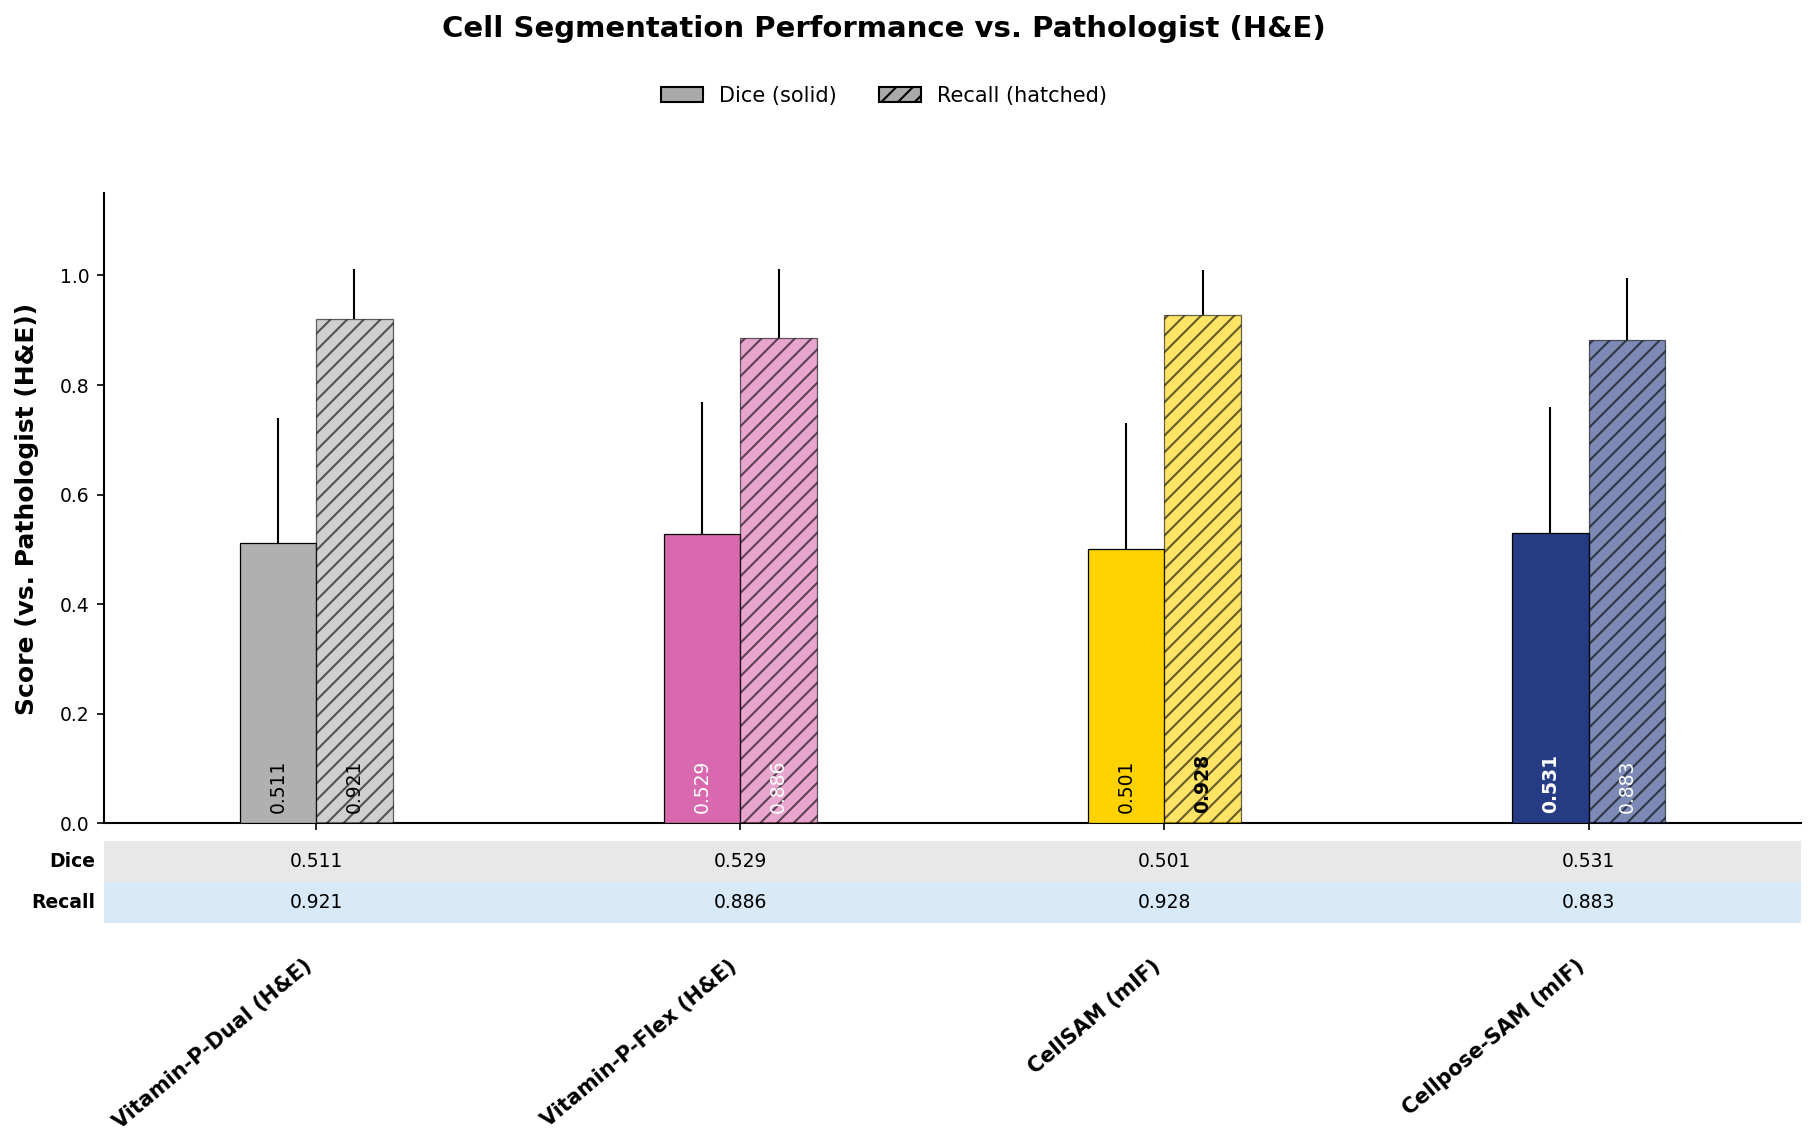

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'Arial'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.0,
})

order = [
    'Vitamin-P-Dual (H&E)',
    'Vitamin-P-Flex (H&E)',
    'CellSAM (mIF)',
    'Cellpose-SAM (mIF)',
]

dice_data = {
    order[0]: [0.5639, 0.5777, 0.8066, 0.8184, 0.5797, 0.6010, 0.7225, 0.6608, 0.5859, 0.3753,
               0.7737, 0.5903, 0.6066, 0.4255, 0.7334, 0.3361, 0.4534, 0.1906, 0.8206, 0.2755,
               0.2786, 0.0305, 0.4588, 0.0102],
    order[1]: [0.6104, 0.5906, 0.8166, 0.8273, 0.5738, 0.6531, 0.7700, 0.7991, 0.6212, 0.3753,
               0.7443, 0.6957, 0.6206, 0.3779, 0.6611, 0.3427, 0.4369, 0.1976, 0.8599, 0.2686,
               0.2846, 0.0298, 0.5174, 0.0097],
    order[2]: [0.5513, 0.5812, 0.7975, 0.8069, 0.5537, 0.5776, 0.7136, 0.6847, 0.5591, 0.3277,
               0.7643, 0.6141, 0.6149, 0.4412, 0.6994, 0.3447, 0.3855, 0.1814, 0.8246, 0.2736,
               0.2656, 0.0292, 0.4242, 0.0086],
    order[3]: [0.6001, 0.6068, 0.8028, 0.8273, 0.5762, 0.6224, 0.7468, 0.7507, 0.5846, 0.4582,
               0.7657, 0.6228, 0.6359, 0.4003, 0.7398, 0.3652, 0.4466, 0.1960, 0.8260, 0.2870,
               0.3184, 0.0405, 0.5029, 0.0123],
}

recall_data = {
    order[0]: [0.9687, 0.9643, 0.9427, 0.9847, 0.8278, 0.9845, 0.9898, 0.9624, 0.9745, 0.7864,
               0.9242, 0.9535, 0.9074, 0.5564, 0.8685, 0.9169, 0.8836, 0.9227, 0.9849, 0.9584,
               0.9592, 1.0000, 0.9635, 0.9132],
    order[1]: [0.9410, 0.9663, 0.9315, 0.9908, 0.9224, 0.9378, 0.9939, 0.9621, 0.9204, 0.6594,
               0.7634, 0.9620, 0.8458, 0.4154, 0.7872, 0.9202, 0.8242, 0.9364, 0.9806, 0.8408,
               0.9245, 0.9812, 0.9466, 0.9132],
    order[2]: [0.9703, 0.9281, 0.9008, 0.9806, 0.9805, 0.9752, 0.9929, 0.9928, 0.9553, 0.7079,
               0.9571, 0.8967, 0.8692, 0.6603, 0.9240, 0.9028, 0.9319, 0.9075, 0.9834, 0.9306,
               0.9791, 1.0000, 0.9639, 0.9860],
    order[3]: [0.9106, 0.9087, 0.8685, 0.9542, 0.9570, 0.9733, 0.9674, 0.9543, 0.9152, 0.9466,
               0.9482, 0.8731, 0.8299, 0.4160, 0.8570, 0.7940, 0.7628, 0.8530, 0.9731, 0.9278,
               0.8728, 0.9274, 0.9238, 0.8713],
}

colors = {
    order[0]: '#b0b0b0',
    order[1]: '#d969ae',
    order[2]: '#ffd200',
    order[3]: '#253c84',
}
text_colors = {
    order[0]: 'black',
    order[1]: 'white',
    order[2]: 'black',
    order[3]: 'white',
}

dice_means   = {m: np.mean(v) for m, v in dice_data.items()}
dice_stds    = {m: np.std(v)  for m, v in dice_data.items()}
recall_means = {m: np.mean(v) for m, v in recall_data.items()}
recall_stds  = {m: np.std(v)  for m, v in recall_data.items()}

n_models = len(order)
bar_width = 0.18
x        = np.arange(n_models)
dice_x   = x - bar_width / 2
recall_x = x + bar_width / 2

fig, ax = plt.subplots(figsize=(13, 7), facecolor='white', dpi=150)

best_dice_mean   = max(dice_means.values())
best_recall_mean = max(recall_means.values())

for i, model in enumerate(order):
    c     = colors[model]
    txt_c = text_colors[model]

    # Dice bar — solid
    d_mean, d_std = dice_means[model], dice_stds[model]
    ax.bar(dice_x[i], d_mean, bar_width, color=c, edgecolor='black', linewidth=0.6, zorder=3)
    ax.errorbar(dice_x[i], d_mean, yerr=[[0], [d_std]],
                fmt='none', ecolor='black', elinewidth=1, capsize=0, zorder=4)
    fw = 'bold' if d_mean == best_dice_mean else 'normal'
    ax.text(dice_x[i], 0.02, f'{d_mean:.3f}', ha='center', va='bottom', rotation=90,
            color=txt_c, fontsize=9, fontweight=fw, zorder=5)

    # Recall bar — hatched
    r_mean, r_std = recall_means[model], recall_stds[model]
    ax.bar(recall_x[i], r_mean, bar_width, color=c, edgecolor='black', linewidth=0.6,
           hatch='///', alpha=0.6, zorder=3)
    ax.errorbar(recall_x[i], r_mean, yerr=[[0], [r_std]],
                fmt='none', ecolor='black', elinewidth=1, capsize=0, zorder=4)
    fw = 'bold' if r_mean == best_recall_mean else 'normal'
    ax.text(recall_x[i], 0.02, f'{r_mean:.3f}', ha='center', va='bottom', rotation=90,
            color=txt_c, fontsize=9, fontweight=fw, zorder=5)

# Axes
ax.set_ylim(0.0, 1.15)
ax.set_xlim(-0.5, n_models - 0.5)
ax.set_ylabel('Score (vs. Pathologist (H&E))', fontsize=12, labelpad=10, fontweight='bold')
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(x)
ax.set_xticklabels(['' for _ in order])

# Table below — only Dice and Recall labels (H&E), no bold underlines
table_y_start = -0.06
row_height    = 0.065
row_configs   = [
    ('Dice',   dice_means,   None),
    ('Recall', recall_means, None),
]
bg_colors_table = ['#e8e8e8', '#d8eaf7']

for r, (label, stat_dict, _) in enumerate(row_configs):
    row_y = table_y_start - (r * row_height)
    rect_patch = plt.Rectangle((-0.5, row_y - row_height / 2), n_models, row_height,
                                facecolor=bg_colors_table[r],
                                transform=ax.get_xaxis_transform(),
                                zorder=0, clip_on=False)
    ax.add_patch(rect_patch)
    ax.text(-0.52, row_y, label, ha='right', va='center',
            transform=ax.get_xaxis_transform(), fontweight='bold', fontsize=9)
    for idx_col, model in enumerate(order):
        val = stat_dict[model]
        ax.text(idx_col, row_y, f'{val:.3f}', ha='center', va='center',
                transform=ax.get_xaxis_transform(), fontsize=9)

# Diagonal model labels
for idx_col, model in enumerate(order):
    ax.text(idx_col, table_y_start - (len(row_configs) * row_height) - 0.02,
            model.replace('\n', ' '), ha='right', va='top', rotation=40,
            transform=ax.get_xaxis_transform(), fontsize=10, fontweight='bold')

# Legend — only Dice vs Recall distinction
dice_patch   = Patch(facecolor='darkgrey', edgecolor='black', label='Dice (solid)')
recall_patch = Patch(facecolor='darkgrey', edgecolor='black', hatch='///', label='Recall (hatched)')
fig.legend(handles=[dice_patch, recall_patch],
           loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=2, frameon=False, fontsize=10)

fig.suptitle('Cell Segmentation Performance vs. Pathologist (H&E)', fontsize=14,
             fontweight='bold', y=1.07)

plt.subplots_adjust(bottom=0.30, top=0.90, left=0.10, right=0.97)
# plt.savefig('combined_dice_recall.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()

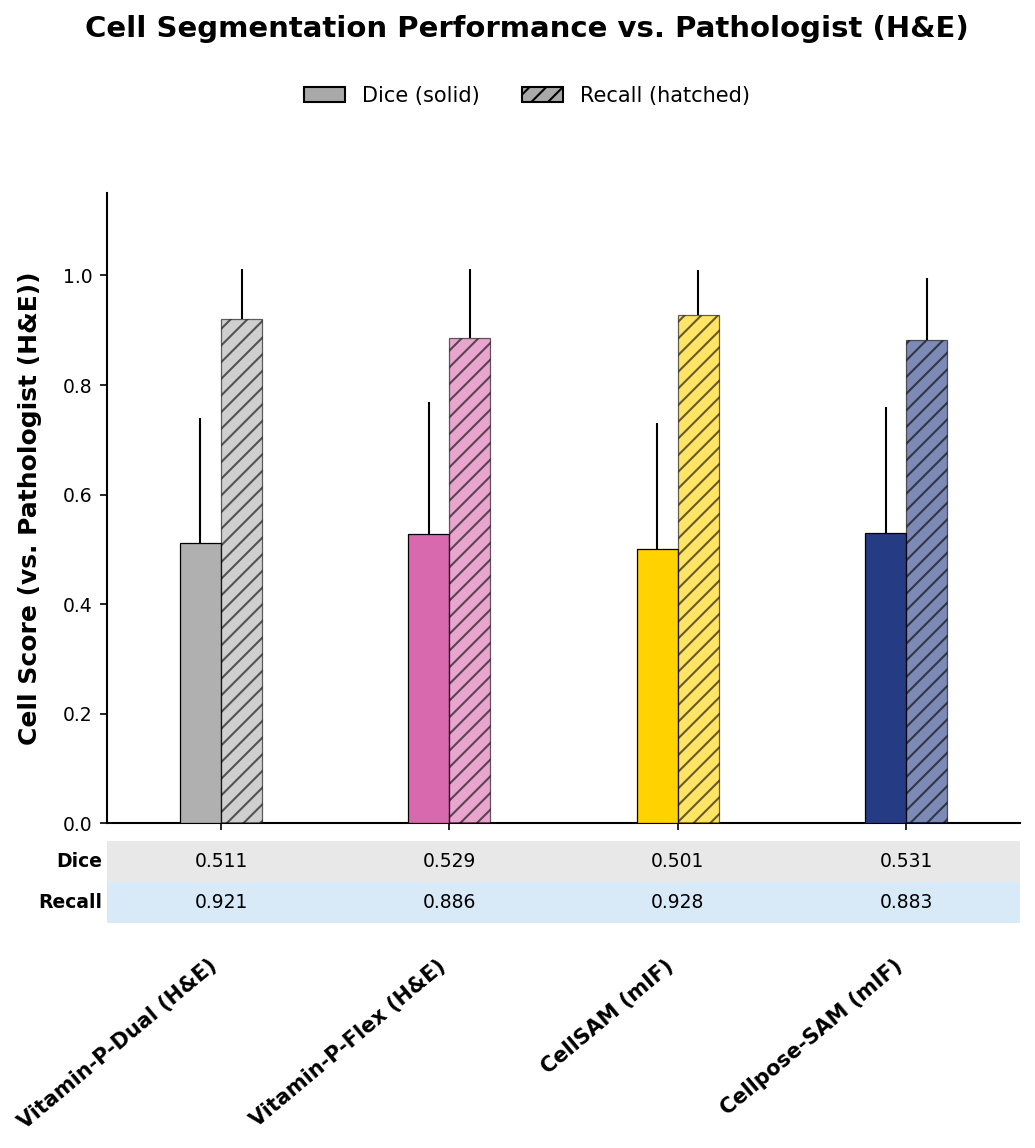

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'Arial'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.0,
})

order = [
    'Vitamin-P-Dual (H&E)',
    'Vitamin-P-Flex (H&E)',
    'CellSAM (mIF)',
    'Cellpose-SAM (mIF)',
]

dice_data = {
    order[0]: [0.5639, 0.5777, 0.8066, 0.8184, 0.5797, 0.6010, 0.7225, 0.6608, 0.5859, 0.3753,
               0.7737, 0.5903, 0.6066, 0.4255, 0.7334, 0.3361, 0.4534, 0.1906, 0.8206, 0.2755,
               0.2786, 0.0305, 0.4588, 0.0102],
    order[1]: [0.6104, 0.5906, 0.8166, 0.8273, 0.5738, 0.6531, 0.7700, 0.7991, 0.6212, 0.3753,
               0.7443, 0.6957, 0.6206, 0.3779, 0.6611, 0.3427, 0.4369, 0.1976, 0.8599, 0.2686,
               0.2846, 0.0298, 0.5174, 0.0097],
    order[2]: [0.5513, 0.5812, 0.7975, 0.8069, 0.5537, 0.5776, 0.7136, 0.6847, 0.5591, 0.3277,
               0.7643, 0.6141, 0.6149, 0.4412, 0.6994, 0.3447, 0.3855, 0.1814, 0.8246, 0.2736,
               0.2656, 0.0292, 0.4242, 0.0086],
    order[3]: [0.6001, 0.6068, 0.8028, 0.8273, 0.5762, 0.6224, 0.7468, 0.7507, 0.5846, 0.4582,
               0.7657, 0.6228, 0.6359, 0.4003, 0.7398, 0.3652, 0.4466, 0.1960, 0.8260, 0.2870,
               0.3184, 0.0405, 0.5029, 0.0123],
}

recall_data = {
    order[0]: [0.9687, 0.9643, 0.9427, 0.9847, 0.8278, 0.9845, 0.9898, 0.9624, 0.9745, 0.7864,
               0.9242, 0.9535, 0.9074, 0.5564, 0.8685, 0.9169, 0.8836, 0.9227, 0.9849, 0.9584,
               0.9592, 1.0000, 0.9635, 0.9132],
    order[1]: [0.9410, 0.9663, 0.9315, 0.9908, 0.9224, 0.9378, 0.9939, 0.9621, 0.9204, 0.6594,
               0.7634, 0.9620, 0.8458, 0.4154, 0.7872, 0.9202, 0.8242, 0.9364, 0.9806, 0.8408,
               0.9245, 0.9812, 0.9466, 0.9132],
    order[2]: [0.9703, 0.9281, 0.9008, 0.9806, 0.9805, 0.9752, 0.9929, 0.9928, 0.9553, 0.7079,
               0.9571, 0.8967, 0.8692, 0.6603, 0.9240, 0.9028, 0.9319, 0.9075, 0.9834, 0.9306,
               0.9791, 1.0000, 0.9639, 0.9860],
    order[3]: [0.9106, 0.9087, 0.8685, 0.9542, 0.9570, 0.9733, 0.9674, 0.9543, 0.9152, 0.9466,
               0.9482, 0.8731, 0.8299, 0.4160, 0.8570, 0.7940, 0.7628, 0.8530, 0.9731, 0.9278,
               0.8728, 0.9274, 0.9238, 0.8713],
}

colors = {
    order[0]: '#b0b0b0',
    order[1]: '#d969ae',
    order[2]: '#ffd200',
    order[3]: '#253c84',
}
text_colors = {
    order[0]: 'black',
    order[1]: 'white',
    order[2]: 'black',
    order[3]: 'white',
}

dice_means   = {m: np.mean(v) for m, v in dice_data.items()}
dice_stds    = {m: np.std(v)  for m, v in dice_data.items()}
recall_means = {m: np.mean(v) for m, v in recall_data.items()}
recall_stds  = {m: np.std(v)  for m, v in recall_data.items()}

n_models = len(order)
bar_width = 0.18
x        = np.arange(n_models)
dice_x   = x - bar_width / 2
recall_x = x + bar_width / 2

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white', dpi=150)

best_dice_mean   = max(dice_means.values())
best_recall_mean = max(recall_means.values())

for i, model in enumerate(order):
    c     = colors[model]
    txt_c = text_colors[model]

    # Dice bar — solid
    d_mean, d_std = dice_means[model], dice_stds[model]
    ax.bar(dice_x[i], d_mean, bar_width, color=c, edgecolor='black', linewidth=0.6, zorder=3)
    ax.errorbar(dice_x[i], d_mean, yerr=[[0], [d_std]],
                fmt='none', ecolor='black', elinewidth=1, capsize=0, zorder=4)
    fw = 'bold' if d_mean == best_dice_mean else 'normal'
    # ax.text(dice_x[i], 0.02, f'{d_mean:.3f}', ha='center', va='bottom', rotation=90,
    #         color=txt_c, fontsize=9, fontweight=fw, zorder=5)

    # Recall bar — hatched
    r_mean, r_std = recall_means[model], recall_stds[model]
    ax.bar(recall_x[i], r_mean, bar_width, color=c, edgecolor='black', linewidth=0.6,
           hatch='///', alpha=0.6, zorder=3)
    ax.errorbar(recall_x[i], r_mean, yerr=[[0], [r_std]],
                fmt='none', ecolor='black', elinewidth=1, capsize=0, zorder=4)
    fw = 'bold' if r_mean == best_recall_mean else 'normal'
    # ax.text(recall_x[i], 0.02, f'{r_mean:.3f}', ha='center', va='bottom', rotation=90,
    #         color=txt_c, fontsize=9, fontweight=fw, zorder=5)

# Axes
ax.set_ylim(0.0, 1.15)
ax.set_xlim(-0.5, n_models - 0.5)
ax.set_ylabel('Cell Score (vs. Pathologist (H&E))', fontsize=12, labelpad=10, fontweight='bold')
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(x)
ax.set_xticklabels(['' for _ in order])

# Table below — only Dice and Recall labels (H&E), no bold underlines
table_y_start = -0.06
row_height    = 0.065
row_configs   = [
    ('Dice',   dice_means,   None),
    ('Recall', recall_means, None),
]
bg_colors_table = ['#e8e8e8', '#d8eaf7']

for r, (label, stat_dict, _) in enumerate(row_configs):
    row_y = table_y_start - (r * row_height)
    rect_patch = plt.Rectangle((-0.5, row_y - row_height / 2), n_models, row_height,
                                facecolor=bg_colors_table[r],
                                transform=ax.get_xaxis_transform(),
                                zorder=0, clip_on=False)
    ax.add_patch(rect_patch)
    ax.text(-0.52, row_y, label, ha='right', va='center',
            transform=ax.get_xaxis_transform(), fontweight='bold', fontsize=9)
    for idx_col, model in enumerate(order):
        val = stat_dict[model]
        ax.text(idx_col, row_y, f'{val:.3f}', ha='center', va='center',
                transform=ax.get_xaxis_transform(), fontsize=9)

# Diagonal model labels
for idx_col, model in enumerate(order):
    ax.text(idx_col, table_y_start - (len(row_configs) * row_height) - 0.02,
            model.replace('\n', ' '), ha='right', va='top', rotation=40,
            transform=ax.get_xaxis_transform(), fontsize=10, fontweight='bold')

# Legend — only Dice vs Recall distinction
dice_patch   = Patch(facecolor='darkgrey', edgecolor='black', label='Dice (solid)')
recall_patch = Patch(facecolor='darkgrey', edgecolor='black', hatch='///', label='Recall (hatched)')
fig.legend(handles=[dice_patch, recall_patch],
           loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=2, frameon=False, fontsize=10)

fig.suptitle('Cell Segmentation Performance vs. Pathologist (H&E)', fontsize=14,
             fontweight='bold', y=1.07)

plt.subplots_adjust(bottom=0.30, top=0.90, left=0.10, right=0.97)
plt.savefig('combined_dice_recall.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()